# EDA

**Project Objective:**  
Analyze the dataset and add columns that will help with further analysis

**Business Questions:**  
1. During which months is most profit generated?
2. Which customers generate the most revenue?  
3. Where should marketing focus for retention and engagement?

**Tools Used:**  
- Python (pandas, seaborn, matplotlib)

**Key Insights:**  
- Retention drops sharply after the first month.
- Loyal Customers contribute the largest share of revenue (~11.6M).
- Most customers are one-time buyers as shown by the heatmap, highlighting opportunities to improve repeat purchase behavior.


# EDA (Exploratory Data Analysis)

In [61]:
import pandas as pd

In [62]:
df = pd.read_csv('/Users/aaliyahgritly/Downloads/Bebo study items/(P3) E-commerce project/cleaned_online_retail_II.csv')

df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Add new columns
You create new columns to add more metrics that can be useful for business isnights

Create a new column `revenue`

In [63]:
df["revenue"] = df["quantity"] * df["price"]

In [64]:
df[["revenue", "price", "quantity"]].head()

,revenue,price,quantity
0,83.4,6.95,12
1,81.0,6.75,12
2,81.0,6.75,12
3,100.8,2.10,48
4,30.0,1.25,24


Create `total_customers`

In [81]:
df['customer_id'].nunique()
print(f"Total unique customers are: {df['customer_id'].nunique()}")

Total unique customers are: 5878


Create `total_orders` 

In [66]:
total_orders = df['invoice'].nunique()
print(f"Total orders are: {total_orders}")

Total orders are: 36969


Create `total_revenue` 

In [67]:
total_revenue = df['revenue'].sum()
print(f"Total revenue is: {total_revenue}")

Total revenue is: 17374804.268


Create `orders_per_customer`. 
This way we can segment customers to see how frequent they have purchased from you.

In [68]:
# this gives us the number of unique orders per customer
orders_per_customer = df.groupby("customer_id")["invoice"].nunique().reset_index(name = "order_count")

In [73]:
orders_per_customer.sort_values(by="order_count", ascending=False).head() # shows top 5 customers with most orders

,customer_id,order_count,customer_type
2538,14911.0,398,Loyal
400,12748.0,336,Loyal
5433,17841.0,211,Loyal
2935,15311.0,208,Loyal
739,13089.0,203,Loyal


Check 1-time customers vs repeat buyers

In [ ]:
orders_per_customer['customer_type'] = orders_per_customer['order_count'].apply(lambda x: "One-time" if x == 1 else ("Repeat" if x <= 10 else "Loyal"))

In [144]:
orders_per_customer['customer_type'].value_counts()

customer_type
Repeat      3379
One-time    1623
Loyal        876
Name: count, dtype: int64

### Insights
- About 57.5 % of customers are repeat buyers, meaning there is a litte bit of a churn.
- Loyal customers make about 14.9 % of all cusotmers, but still bring in the most revenue, which suggests that retaining them is important.
- Loyal and repeat customers generate consistent revenue.
- This classification of customers will help us track retention and segment customers by value later on.

Create a `customer_type` column

In [75]:
df['customer_type'] = orders_per_customer['customer_type']

In [120]:
df.sample(10)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,customer_type
34611,494046,21499,BLUE SPOTS WRAP,25,2010-01-11 12:01:00,0.42,15044.0,United Kingdom,10.50,Loyal
713788,575127,48184,DOORMAT ENGLISH ROSE,2,2011-11-08 14:26:00,8.25,13695.0,United Kingdom,16.50,Loyal
619055,566047,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,12,2011-09-08 14:19:00,1.25,17370.0,United Kingdom,15.00,Repeat
223886,518261,22189,CREAM HEART CARD HOLDER,5,2010-08-05 18:42:00,3.95,17921.0,United Kingdom,19.75,Repeat
313531,528383,22405,MONEY BOX POCKET MONEY DESIGN,2,2010-10-21 18:21:00,1.25,14686.0,United Kingdom,2.50,Repeat
495142,550476,84997B,CHILDRENS CUTLERY RETROSPOT RED,12,2011-04-18 14:00:00,3.39,15769.0,United Kingdom,40.68,Loyal
281534,525037,22694,WICKER STAR,12,2010-10-03 12:40:00,2.10,14911.0,EIRE,25.20,Loyal
722011,575936,23119,PACK OF 6 LARGE FRUIT STRAWS,12,2011-11-13 11:21:00,0.62,17041.0,United Kingdom,7.44,Repeat
627829,566875,85099F,JUMBO BAG STRAWBERRY,100,2011-09-15 13:43:00,1.79,17669.0,United Kingdom,179.00,Repeat
130971,506293,35924,HANGING FAIRY CAKE DECORATION,72,2010-04-29 09:42:00,1.69,13802.0,United Kingdom,121.68,Loyal


Create `revenue_over_time`

In [79]:
# resampling to find monthly revenue
monthly_revenue = (df.set_index("invoicedate").resample("M")["revenue"].sum()) # resample by month and sum revenue

monthly_revenue.head()

/var/folders/sk/lq_95tyx0mvg_8rph7dgqtwm0000gn/T/ipykernel_22025/23342793.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = (df.set_index("invoicedate").resample("M")["revenue"].sum()) # resample by month and sum revenue


invoicedate
2009-12-31    683504.010
2010-01-31    555802.672
2010-02-28    504558.956
2010-03-31    696978.471
2010-04-30    591982.002
Freq: ME, Name: revenue, dtype: float64

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='invoicedate'>

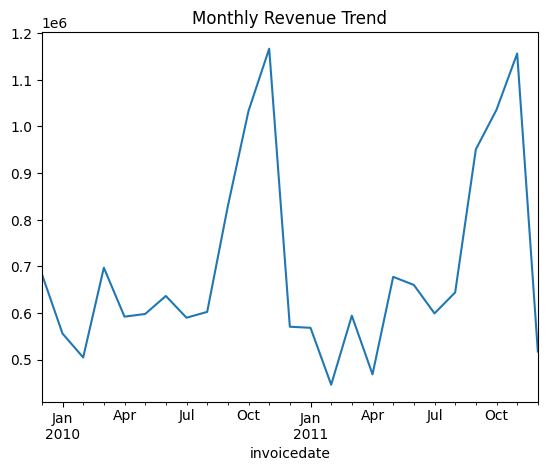

In [58]:
monthly_revenue.plot(title="Monthly Revenue Trend")


### Insights
- Vast majority of revenue comes from the UK, so it is better to focus efforts (shipping, etc.) on those customers.
- Sales seem to start improving during August, and peaking in October.
- Lowest sales happen from February to April.

In [80]:
country_revenue = (df.groupby("country")["revenue"].sum().sort_values(ascending=False))

country_revenue.head(10)


country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: revenue, dtype: float64

In [123]:
df.shape

(779425, 10)

In [124]:
df[["customer_id", "invoice", "quantity", "price", "revenue"]].head()


,customer_id,invoice,quantity,price,revenue
0,13085.0,489434,12,6.95,83.4
1,13085.0,489434,12,6.75,81.0
2,13085.0,489434,12,6.75,81.0
3,13085.0,489434,48,2.10,100.8
4,13085.0,489434,24,1.25,30.0


In [125]:
total_customers = df["customer_id"].nunique()
total_orders = df["invoice"].nunique()
total_revenue = df["revenue"].sum()

print("Customers:", total_customers)
print("Orders:", total_orders)
print("Revenue:", round(total_revenue, 2))


Customers: 5878
Orders: 36969
Revenue: 17374804.27


In [126]:
orders_per_customer.describe()

,customer_id,order_count
count,5878.000000,5878.000000
mean,15315.313542,6.289384
std,1715.572666,13.009406
min,12346.000000,1.000000
25%,13833.250000,1.000000
50%,15314.500000,3.000000
75%,16797.750000,7.000000
max,18287.000000,398.000000


In [129]:
# df.merge combines the customer type information back into the original dataframe, aligning it by customer_id.
df = df.merge(orders_per_customer[["customer_id", "customer_type"]], on = "customer_id", how = "left")

In [134]:
df['customer_type_x'].isna().sum()

np.int64(0)

In [137]:
df = (df.drop(columns=['customer_type_x']).rename(columns = {'customer_type_y': 'customer_type'}))

In [140]:
df.sample(10)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,customer_type
602808,564037,21163,DO NOT TOUCH MY STUFF DOOR HANGER,2,2011-08-22 12:26:00,0.39,14800.0,United Kingdom,0.78,Loyal
167844,511209,22704,WRAP RED APPLES,25,2010-06-07 12:18:00,0.42,16719.0,United Kingdom,10.50,Loyal
539237,556245,22921,HERB MARKER CHIVES,1,2011-06-09 16:10:00,0.65,17841.0,United Kingdom,0.65,Loyal
55651,496919,22150,3 STRIPEY MICE FELTCRAFT,6,2010-02-04 15:41:00,1.95,16986.0,United Kingdom,11.70,Loyal
234042,519617,21668,RED STRIPE CERAMIC DRAWER KNOB,12,2010-08-19 09:10:00,1.25,14540.0,United Kingdom,15.00,Loyal
132715,506555,20677,PINK SPOTTY BOWL,8,2010-04-30 11:25:00,1.25,17677.0,United Kingdom,10.00,Loyal
445385,544399,22584,PACK OF 6 PANNETONE GIFT BOXES,6,2011-02-18 12:28:00,2.55,12594.0,Italy,15.30,Loyal
543879,556882,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,16,2011-06-15 12:21:00,0.65,14395.0,United Kingdom,10.40,Loyal
772676,580877,20973,12 PENCIL SMALL TUBE WOODLAND,3,2011-12-06 12:15:00,0.65,17250.0,United Kingdom,1.95,Repeat
437450,543285,22904,CALENDAR PAPER CUT DESIGN,6,2011-02-07 09:48:00,2.95,14600.0,United Kingdom,17.70,Repeat


In [149]:
df[['customer_id', 'customer_type']].drop_duplicates().head()

,customer_id,customer_type
0,13085.0,Repeat
12,13078.0,Loyal
31,15362.0,Repeat
54,18102.0,Loyal
71,12682.0,Loyal


In [150]:
df['customer_type'].value_counts()

customer_type
Loyal       427289
Repeat      317830
One-time     34306
Name: count, dtype: int64

In [154]:
df.to_csv('/Users/aaliyahgritly/Downloads/Bebo study items/(P3) E-commerce project/cleaned_online_retail_II.csv', index=False) 

# Revenue by Customer Type

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Calculate revenue by customer type
revenue_by_type = df.groupby("customer_type")["revenue"].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_type.index, y=revenue_by_type.values, palette="viridis")
plt.title("Total Revenue by Customer Type", fontsize=14, fontweight="bold")
plt.xlabel("Customer Type", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(revenue_by_type.values):
    plt.text(i, v + 100000, f"${v:,.0f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

# Display summary
print("Revenue by Customer Type:")
print(revenue_by_type)